# 📈 Tahap 3 — Exploratory Data Analysis (EDA)

---

EDA artinya kita **kenalan dulu sama data sebelum bikin model.**

Caranya: ajukan pertanyaan → jawab pakai grafik dan angka.

### Yang akan kita cari tahu:

| # | Pertanyaan |
|---|---|
| 1 | Dari semua pertandingan, lebih sering menang, seri, atau kalah? |
| 2 | Negara mana yang paling sering menang di World Cup? |
| 3 | Makin lama, makin sedikit gol atau makin banyak? |
| 4 | Tim yang main di kandang sendiri lebih sering menang? |
| 5 | Negara yang kaya (GDP tinggi) lebih sering menang? |
| 6 | Faktor apa saja yang paling berpengaruh terhadap kemenangan? |
| 7 | Skor berapa yang paling sering muncul? |

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print('Library siap ✅')

Library siap ✅


## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/wc_clean.csv', parse_dates=['date'])
win_rate = pd.read_csv('../data/processed/win_rate_per_team.csv')

print(f'Total pertandingan World Cup : {len(df)}')
print(f'Total tim                    : {len(win_rate)}')
df.head()

Total pertandingan World Cup : 980
Total tim                    : 84


,date,year,home_team,away_team,home_score,away_score,goal_diff,home_win_rate,away_win_rate,win_rate_diff,neutral,result
0,1930-07-13,1930,Belgium,United States,0,3,-3,0.404,0.263,0.141,1,L
1,1930-07-13,1930,France,Mexico,4,1,3,0.534,0.295,0.239,1,W
2,1930-07-14,1930,Brazil,Yugoslavia,1,2,-1,0.661,0.424,0.237,1,L
3,1930-07-14,1930,Peru,Romania,1,3,-2,0.278,0.381,-0.103,1,L
4,1930-07-15,1930,Argentina,France,1,0,1,0.534,0.534,0.000,1,W


---
## ❓ Pertanyaan 1: Lebih sering menang, seri, atau kalah?

Kita lihat dari sudut pandang **tim yang namanya disebutkan pertama** (tim "home") di setiap pertandingan.

- **W** = Menang
- **D** = Seri
- **L** = Kalah

Ini penting karena kita perlu tahu: apakah jumlah data menang/seri/kalah kira-kira seimbang? Kalau tidak seimbang, model kita bisa jadi malas dan cuma tebak satu jawaban terus.

Distribusi hasil pertandingan:
        Jumlah  Persentase (%)
result                        
W          446            45.5
L          312            31.8
D          222            22.7


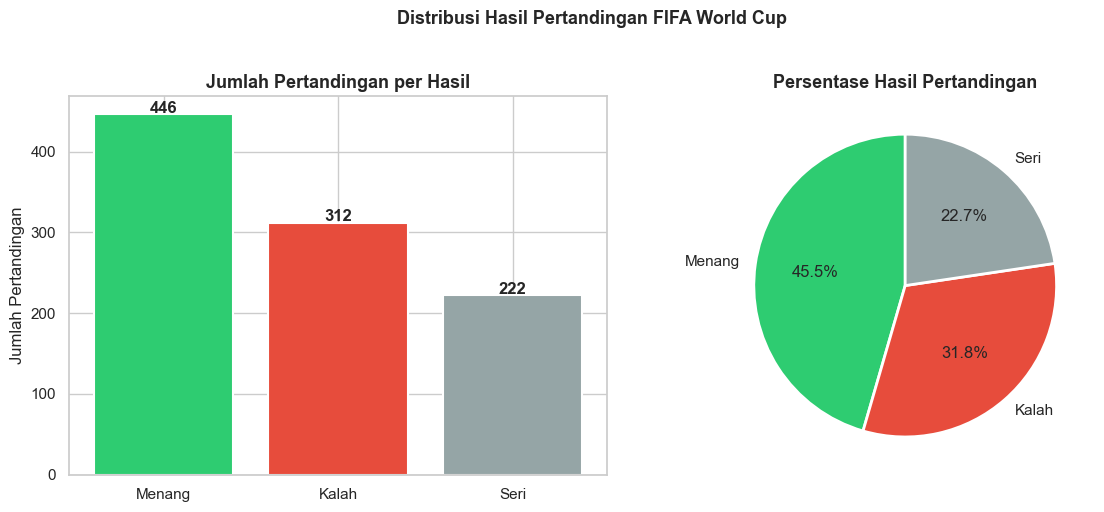

In [3]:
result_counts = df['result'].value_counts()
result_pct = df['result'].value_counts(normalize=True) * 100

print('Distribusi hasil pertandingan:')
summary = pd.DataFrame({'Jumlah': result_counts, 'Persentase (%)': result_pct.round(1)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
labels_map = {'W': 'Menang', 'L': 'Kalah', 'D': 'Seri'}

axes[0].bar([labels_map.get(k, k) for k in result_counts.index],
            result_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Pertandingan per Hasil', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pertandingan')
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(result_pct.values,
            labels=[labels_map.get(k, k) for k in result_pct.index],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Persentase Hasil Pertandingan', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Hasil Pertandingan FIFA World Cup', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

- Tim yang disebutkan pertama **lebih sering menang** daripada kalah.
- Tapi selisihnya tidak terlalu jauh — artinya data kita **cukup seimbang**, dan model ML kita tidak akan asal tebak satu jawaban terus.
- Seri juga cukup sering terjadi — ini yang membuat prediksi bola jadi susah, karena ada 3 kemungkinan hasil, bukan cuma 2.

> **Intinya:** Data kita oke untuk dipakai latih model. Tidak ada satu hasil yang terlalu mendominasi.

---
## ❓ Pertanyaan 2: Negara mana yang paling sering menang?

Kita hitung **win rate** (persentase kemenangan) setiap tim.

Supaya adil, kita hanya tampilkan tim yang sudah main **minimal 10 pertandingan** — karena kalau tim baru main 1 kali dan menang, win rate-nya 100% tapi itu tidak mencerminkan kekuatan aslinya.

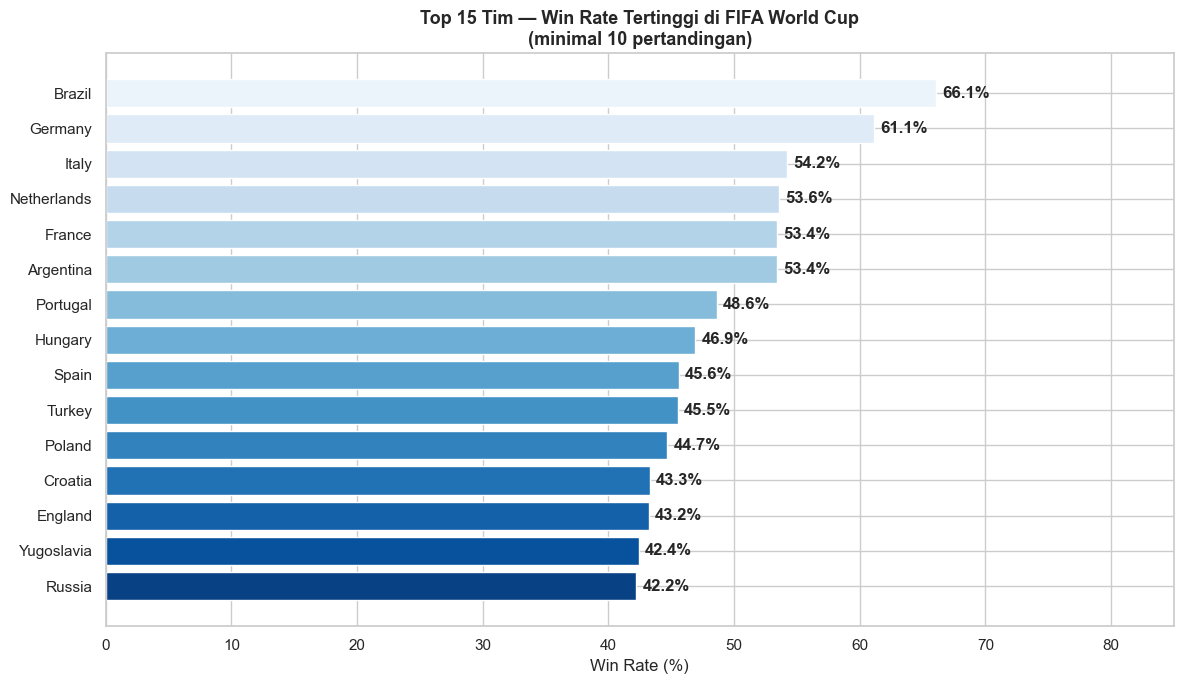

In [4]:
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
total_matches = (home_counts.add(away_counts, fill_value=0)).astype(int)

win_rate_filtered = win_rate.copy()
win_rate_filtered['total_matches'] = win_rate_filtered['team'].map(total_matches)
win_rate_filtered = win_rate_filtered[win_rate_filtered['total_matches'] >= 10]
top15 = win_rate_filtered.sort_values('win_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['team'][::-1], top15['win_rate'][::-1] * 100,
               color=sns.color_palette('Blues_r', 15), edgecolor='white')

for bar, val in zip(bars, top15['win_rate'][::-1] * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_xlabel('Win Rate (%)', fontsize=12)
ax.set_title('Top 15 Tim — Win Rate Tertinggi di FIFA World Cup\n(minimal 10 pertandingan)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 85)
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

- **Brazil, Jerman, Argentina** ada di atas — ini bukan kebetulan. Negara-negara ini sudah punya sistem pembinaan sepak bola yang kuat selama puluhan tahun.
- Beberapa nama mungkin mengejutkan: **Hungary dan Uruguay** muncul tinggi karena mereka sangat dominan di era 1930–1950an, zaman ketika kompetisinya tidak sepanas sekarang.
- **Win rate historis ini akan jadi salah satu fitur paling penting** di model ML kita — karena tim yang sering menang di masa lalu cenderung lebih kuat di masa depan juga.

> **Intinya:** Brazil juara win rate, tapi angka ini perlu dilihat dengan konteks era pertandingannya.

---
## ❓ Pertanyaan 3: Makin lama, makin sedikit gol?

Kita lihat rata-rata jumlah gol per pertandingan dari tahun ke tahun (per dekade).

Ini menarik karena bisa menunjukkan apakah gaya main sepak bola berubah dari waktu ke waktu.

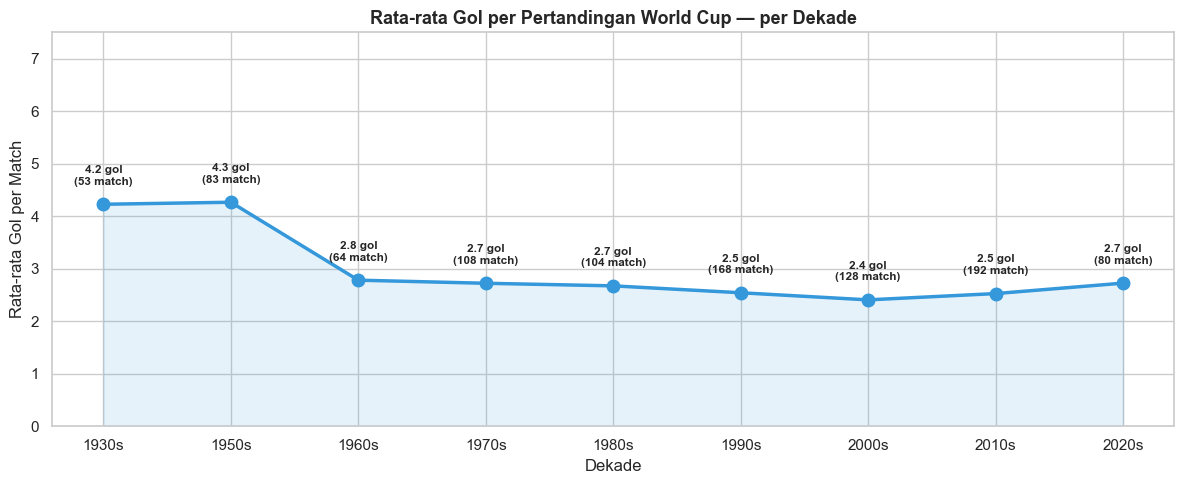

In [5]:
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'
df['total_goals'] = df['home_score'] + df['away_score']

goals_per_decade = df.groupby('decade').agg(
    avg_goals=('total_goals', 'mean'),
    total_matches=('total_goals', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(goals_per_decade['decade'], goals_per_decade['avg_goals'],
        marker='o', linewidth=2.5, markersize=9, color='#3498db')
ax.fill_between(goals_per_decade['decade'], goals_per_decade['avg_goals'],
                alpha=0.12, color='#3498db')

for _, row in goals_per_decade.iterrows():
    ax.annotate(f"{row['avg_goals']:.1f} gol\n({row['total_matches']} match)",
                xy=(row['decade'], row['avg_goals']),
                xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=8.5, fontweight='bold')

ax.set_title('Rata-rata Gol per Pertandingan World Cup — per Dekade',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dekade')
ax.set_ylabel('Rata-rata Gol per Match')
ax.set_ylim(0, 7.5)
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

- **Tahun 1950an adalah era paling banyak gol** — rata-rata hampir 5 gol per pertandingan! Zaman itu taktik bertahan belum secanggih sekarang.
- Makin ke sini, rata-rata gol **makin turun dan stabil** di sekitar 2–3 gol per pertandingan.
- Ini berarti **sepak bola modern lebih ketat dan terorganisir** — pertahanan makin baik, susah mencetak banyak gol.
- Jumlah pertandingan juga makin banyak karena World Cup **makin diperluas** pesertanya.

> **Intinya:** Bola zaman dulu lebih banyak gol. Sekarang lebih susah cetak gol karena pertahanan makin kuat.

---
## ❓ Pertanyaan 4: Main di kandang sendiri lebih sering menang?

Ini yang disebut **home advantage** — keuntungan main di lapangan sendiri.

Di data kita ada kolom `neutral`:
- **0 = Non-netral** → artinya salah satu tim main di negara mereka sendiri (kandang)
- **1 = Netral** → pertandingan di negara ketiga, tidak ada yang punya keuntungan kandang

Kita bandingkan: apakah tim yang main di kandang sendiri lebih sering menang?

Persentase hasil berdasarkan lokasi pertandingan:
result              D     L     W
Kandang Sendiri  18.5  20.2  61.3
Lapangan Netral  23.2  33.5  43.2

Jumlah match di kandang sendiri : 124
Jumlah match di lapangan netral : 856


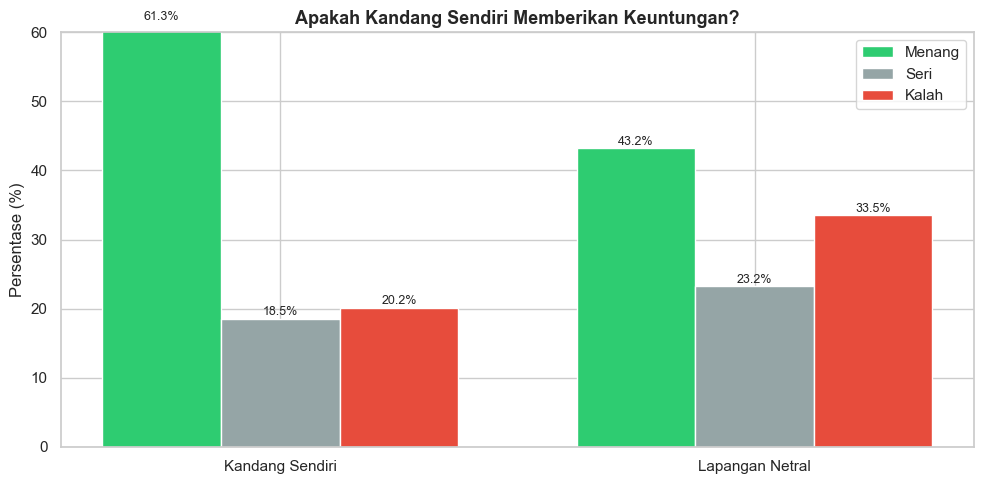

In [6]:
home_adv = df.groupby('neutral')['result'].value_counts(normalize=True).unstack().fillna(0) * 100
home_adv.index = ['Kandang Sendiri', 'Lapangan Netral']

print('Persentase hasil berdasarkan lokasi pertandingan:')
print(home_adv.round(1))
print()
print(f"Jumlah match di kandang sendiri : {len(df[df['neutral'] == 0])}")
print(f"Jumlah match di lapangan netral : {len(df[df['neutral'] == 1])}")

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(home_adv.index))
width = 0.25
result_order = ['W', 'D', 'L']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
labels_bar = ['Menang', 'Seri', 'Kalah']

for i, (col, color, label) in enumerate(zip(result_order, colors, labels_bar)):
    if col in home_adv.columns:
        bars = ax.bar([xi + i * width for xi in x], home_adv[col],
                      width=width, label=label, color=color, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(home_adv.index, fontsize=11)
ax.set_ylabel('Persentase (%)')
ax.set_title('Apakah Kandang Sendiri Memberikan Keuntungan?', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

- Tim yang main di **kandang sendiri memang lebih sering menang** dibanding di lapangan netral.
- Tapi bedanya **tidak terlalu besar** — artinya dukungan penonton memang membantu, tapi kualitas tim tetap yang paling menentukan.
- Fakta menarik: **sebagian besar pertandingan World Cup dimainkan di lapangan netral** — jadi keuntungan kandang ini hanya berlaku untuk sedikit pertandingan.

> **Intinya:** Main di kandang sedikit menguntungkan, tapi bukan jaminan menang. Tim lebih bagus tetap lebih sering menang di mana pun.

---
## ❓ Pertanyaan 5: Negara yang lebih kaya lebih sering menang?

**GDP per capita** = rata-rata pendapatan per orang di suatu negara. Semakin tinggi, semakin "kaya" negaranya.

Logikanya: negara kaya punya lebih banyak uang untuk:
- Bangun fasilitas latihan yang bagus
- Bayar pelatih berkualitas
- Kirim pemain ke klub-klub terbaik dunia

Tapi apakah uang benar-benar bisa beli kemenangan di World Cup? Mari kita buktikan.

### 5a. Load Data GDP

In [7]:
# Data World Bank punya 4 baris header yang perlu di-skip
gdp_raw = pd.read_csv('../data/raw/gdp_per_capita.csv', skiprows=4)

print(f'Jumlah negara dalam data GDP: {len(gdp_raw)}')
gdp_raw[['Country Name', 'Country Code', '2000', '2010', '2022']].head()

Jumlah negara dalam data GDP: 266


,Country Name,Country Code,2000,2010,2022
0,Aruba,ABW,20681.023027,24093.140151,30975.998912
1,Africa Eastern and Southern,AFE,706.727261,1628.905248,1679.327622
2,Afghanistan,AFG,174.930991,560.621505,357.261153
3,Africa Western and Central,AFW,518.969226,1662.633658,2138.473153
4,Angola,AGO,563.733796,4101.637156,3682.113151


In [8]:
# Kita pakai rata-rata GDP tahun 2000-2022 (era World Cup modern)
year_cols = [str(y) for y in range(2000, 2023)]
gdp_raw['gdp_avg'] = gdp_raw[year_cols].mean(axis=1)

gdp = gdp_raw[['Country Name', 'Country Code', 'gdp_avg']].dropna(subset=['gdp_avg'])
gdp.columns = ['country_name', 'country_code', 'gdp_avg']

print(f'Negara dengan data GDP lengkap: {len(gdp)}')
print('\n5 negara dengan GDP per capita tertinggi:')
print(gdp.nlargest(5, 'gdp_avg')[['country_name', 'gdp_avg']].to_string(index=False))

Negara dengan data GDP lengkap: 262

5 negara dengan GDP per capita tertinggi:
  country_name       gdp_avg
        Monaco 162301.005488
 Liechtenstein 140861.038381
    Luxembourg 100666.602413
       Bermuda  96448.570151
Cayman Islands  82020.925849


### 5b. Samakan Nama Negara

Masalah klasik di Data Science: **nama yang sama ditulis beda di dua dataset berbeda.**

Contoh: data bola nulis `"South Korea"`, tapi World Bank nulis `"Korea, Rep."` — padahal negara yang sama!

Kalau tidak kita samakan, data dari dua dataset ini tidak bisa digabung.

In [9]:
name_mapping = {
    'Ivory Coast'         : "Cote d'Ivoire",
    'South Korea'         : 'Korea, Rep.',
    'North Korea'         : "Korea, Dem. People's Rep.",
    'Russia'              : 'Russian Federation',
    'DR Congo'            : 'Congo, Dem. Rep.',
    'Republic of Ireland' : 'Ireland',
    'Cape Verde'          : 'Cabo Verde',
    'West Germany'        : 'Germany',
    'German DR'           : 'Germany',
    'Czechoslovakia'      : 'Czech Republic',
    'Yugoslavia'          : 'Serbia',
    'England'             : 'United Kingdom',
    'Scotland'            : 'United Kingdom',
    'Northern Ireland'    : 'United Kingdom',
    'Wales'               : 'United Kingdom',
}

win_rate['country_wb'] = win_rate['team'].replace(name_mapping)
win_rate['country_wb'] = win_rate['country_wb'].fillna(win_rate['team'])

print('Contoh nama yang disesuaikan:')
mapped = win_rate[win_rate['team'] != win_rate['country_wb']][['team', 'country_wb']]
print(mapped.to_string(index=False))

Contoh nama yang disesuaikan:
               team                country_wb
            England            United Kingdom
         Yugoslavia                    Serbia
             Russia        Russian Federation
        Ivory Coast             Cote d'Ivoire
     Czechoslovakia            Czech Republic
          German DR                   Germany
   Northern Ireland            United Kingdom
           Scotland            United Kingdom
        South Korea               Korea, Rep.
Republic of Ireland                   Ireland
        North Korea Korea, Dem. People's Rep.
              Wales            United Kingdom
         Cape Verde                Cabo Verde
           DR Congo          Congo, Dem. Rep.


### 5c. Gabungkan Data & Buat Grafik

In [10]:
merged = win_rate.merge(gdp, left_on='country_wb', right_on='country_name', how='inner')

print(f'Tim yang berhasil digabung dengan data GDP: {len(merged)}')
unmatched = win_rate[~win_rate['country_wb'].isin(gdp['country_name'])]['team'].tolist()
print(f'Tim tidak ter-match ({len(unmatched)}): {unmatched}')

Tim yang berhasil digabung dengan data GDP: 76
Tim tidak ter-match (8): ['Turkey', 'Czechoslovakia', 'Slovakia', 'Czech Republic', 'Iran', 'North Korea', 'Curaçao', 'Egypt']


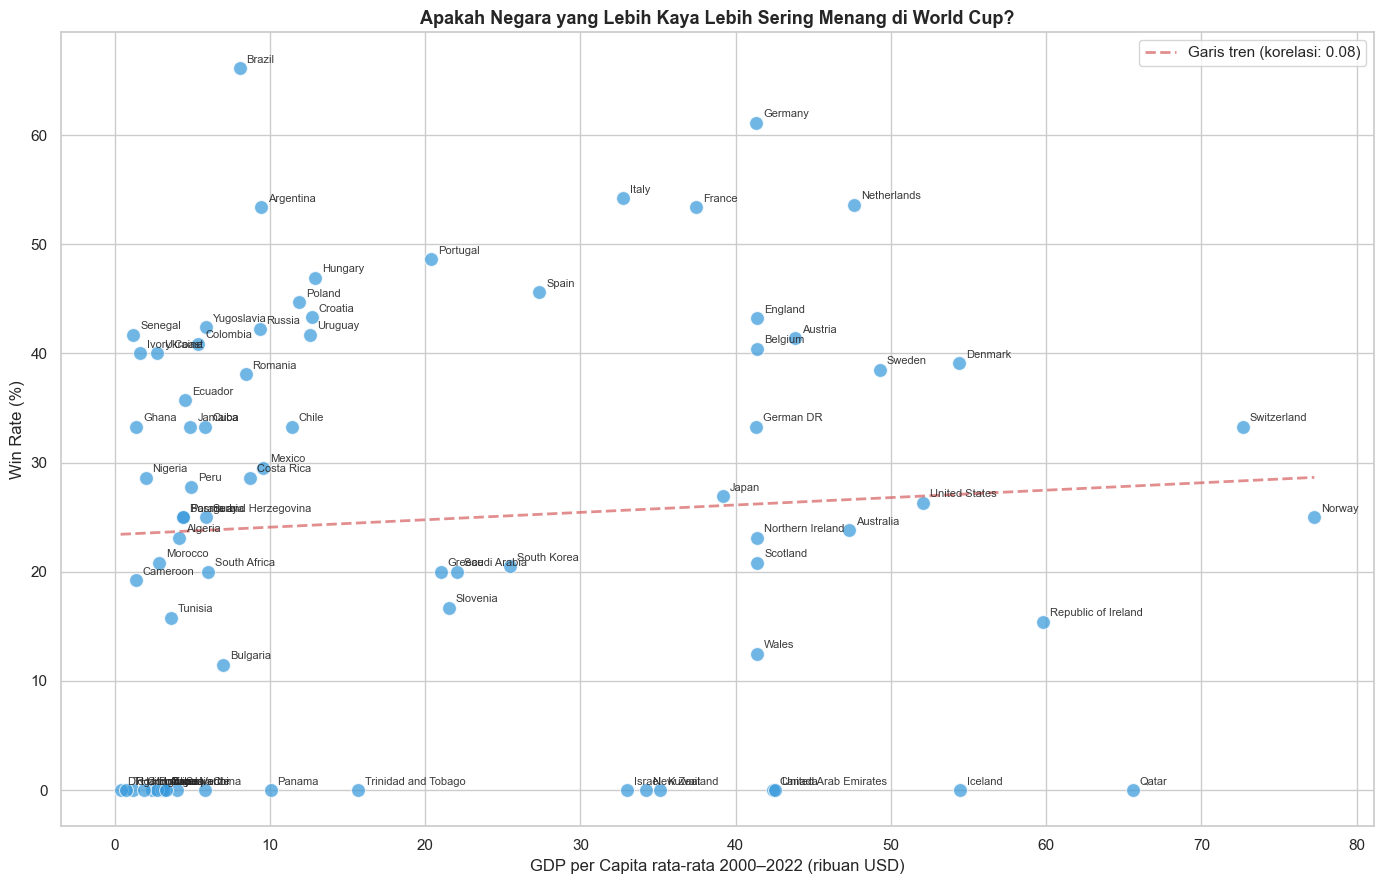


Angka korelasi: 0.075
Skala: -1 = berlawanan total | 0 = tidak ada hubungan | +1 = searah sempurna


In [11]:
correlation_gdp = merged['gdp_avg'].corr(merged['win_rate'])

fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(merged['gdp_avg'] / 1000, merged['win_rate'] * 100,
           alpha=0.7, s=100, color='#3498db', edgecolors='white', linewidth=0.8)

for _, row in merged.iterrows():
    ax.annotate(row['team'],
                xy=(row['gdp_avg'] / 1000, row['win_rate'] * 100),
                xytext=(5, 4), textcoords='offset points',
                fontsize=8, alpha=0.9)

z = np.polyfit(merged['gdp_avg'], merged['win_rate'] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(merged['gdp_avg'].min(), merged['gdp_avg'].max(), 100)
ax.plot(x_line / 1000, p(x_line), 'r--', linewidth=2, alpha=0.7, label=f'Garis tren (korelasi: {correlation_gdp:.2f})')

ax.set_xlabel('GDP per Capita rata-rata 2000–2022 (ribuan USD)', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('Apakah Negara yang Lebih Kaya Lebih Sering Menang di World Cup?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nAngka korelasi: {correlation_gdp:.3f}')
print('Skala: -1 = berlawanan total | 0 = tidak ada hubungan | +1 = searah sempurna')

### 💡 Kesimpulan

- Garis trendnya sedikit naik ke kanan — ada hubungan positif, tapi **sangat lemah**.
- Lihat dua contoh ekstrem ini:
  - 🇧🇷 **Brazil** — GDP-nya biasa saja untuk ukuran negara maju, tapi win rate-nya **tertinggi di dunia**
  - 🇶🇦 **Qatar** — salah satu negara **paling kaya di dunia** (karena minyak), tapi hampir tidak pernah menang di World Cup
- Ini membuktikan bahwa **uang saja tidak cukup** untuk menang di sepak bola. Budaya, sistem pembinaan, dan passion masyarakat terhadap sepak bola jauh lebih penting.

> **Intinya:** Hipotesisnya **sebagian benar** — negara kaya sedikit lebih sering menang, tapi banyak pengecualian. GDP bukan faktor penentu utama.

### 🤔 Tapi Tunggu — Kalau Bukan GDP, Lalu Apa yang Bikin Tim Sepak Bola Bagus?

Pertanyaan bagus. Kita sudah lihat bahwa GDP pengaruhnya lemah. Lalu **apa yang sebenarnya membuat suatu negara punya tim sepak bola yang kuat?**

---

**Yang mendukung "uang (GDP) berpengaruh":**
- Negara Eropa Barat seperti Jerman, Prancis, Spanyol — GDP tinggi, bola bagus
- Uang memang bisa dipakai untuk bangun fasilitas latihan, gaji pelatih top, akademi pemain muda

**Tapi lihat pengecualian ini:**

| Negara | GDP per Capita | Performa Bola |
|---|---|---|
| 🇧🇷 Brazil | Biasa saja | **Tim terkuat dunia** |
| 🇶🇦 Qatar | **Salah satu terkaya di dunia** | Hampir tidak pernah menang |
| 🇦🇷 Argentina | Ekonomi sering krisis | **Juara Dunia 2022** |

---

**Kesimpulan: GDP bisa membantu, tapi tidak bisa membeli ini:**

| Faktor | Penjelasan |
|---|---|
| 🔥 **Budaya & passion** | Di Brazil dan Argentina, bola bukan sekadar olahraga — ini identitas. Anak-anak main bola sejak bisa jalan. |
| 🏫 **Sistem akademi jangka panjang** | Jerman butuh 20+ tahun membangun sistem akademi sebelum dominan. Tidak bisa instan. |
| 👥 **Banyak orang aktif main bola** | Semakin banyak yang main → semakin banyak bakat yang muncul. |
| 🏆 **Kompetisi liga domestik yang keras** | Liga yang ketat melatih pemain jadi tangguh sebelum ke level internasional. |

> **Intinya:** Qatar bisa beli stadion mewah dan pemain naturalisasi, tapi tidak bisa beli **budaya sepak bola yang sudah tumbuh selama 100 tahun**. Itulah kenapa Brazil yang "biasa-biasa saja" ekonominya bisa mengalahkan negara-negara jauh lebih kaya.

### 👨‍💼 Satu Lagi yang Sering Dilupakan: Pelatih (Coach)

Selain budaya dan infrastruktur, ada faktor yang **tidak tertangkap di data kita** tapi pengaruhnya sangat nyata di dunia nyata — yaitu **pelatih**.

---

**Contoh nyata:**

| Pelatih | Tim | Dampak |
|---|---|---|
| **Pep Guardiola** | Barcelona 2008–2012 | Ubah Barcelona jadi tim yang dianggap terbaik sepanjang sejarah |
| **Didier Deschamps** | Prancis 2018 | Bawa Prancis juara dunia dengan pemain yang kata banyak orang "biasa saja" |
| **Jurgen Klopp** | Liverpool 2015–2024 | Dari tim yang hampir degradasi → juara Liga Champions |

---

**Apa yang sebenarnya dilakukan pelatih?**

| Peran | Penjelasan |
|---|---|
| 🧠 **Taktik & strategi** | Menentukan cara bermain, formasi, dan cara menghadapi lawan |
| 💪 **Membangun mental** | Pemain berbakat tapi tidak percaya diri tidak akan bermain maksimal |
| 🤝 **Chemistry tim** | 11 pemain bintang belum tentu menang kalau tidak kompak dan tidak saling percaya |
| 🎯 **Seleksi pemain** | Memilih siapa yang main dan siapa yang tidak — keputusan kecil yang dampaknya besar |

---

**Kenapa faktor pelatih tidak ada di model kita?**

Data yang kita punya hanya berisi **skor dan nama tim** — tidak ada kolom "nama pelatih" atau "taktik yang dipakai". Untuk memasukkan faktor ini ke model ML, kita butuh dataset yang jauh lebih lengkap.

Inilah yang disebut **faktor kualitatif** — nyata dan sangat berpengaruh, tapi susah diukur dengan angka.

> **Intinya:** Data dan model ML kita bagus, tapi tidak sempurna. Selalu ada faktor manusia yang tidak bisa sepenuhnya ditangkap oleh angka — dan pelatih adalah salah satunya. Itulah mengapa prediksi bola tidak pernah 100% akurat, dan itulah yang membuat sepak bola tetap menarik untuk ditonton!

---
## ❓ Pertanyaan 6: Faktor apa yang paling berpengaruh terhadap kemenangan?

Kita sudah tahu GDP tidak terlalu kuat. Lalu **faktor apa yang benar-benar berpengaruh?**

Kita hitung beberapa faktor per tim dari data yang ada:
- **Win rate** — seberapa sering menang secara historis
- **Rata-rata gol cetak** — seberapa kuat serangnya
- **Rata-rata gol kemasukan** — seberapa kuat pertahanannya
- **Pengalaman** — sudah berapa banyak pertandingan dimainkan di World Cup
- **GDP per capita** — kekayaan negara

Lalu kita lihat mana yang paling berkorelasi dengan kemenangan.

In [12]:
# Hitung statistik per tim dari perspektif home
home_stats = df.groupby('home_team').agg(
    goals_scored_home=('home_score', 'mean'),
    goals_conceded_home=('away_score', 'mean'),
    matches_home=('home_score', 'count')
).reset_index().rename(columns={'home_team': 'team'})

# Statistik dari perspektif away
away_stats = df.groupby('away_team').agg(
    goals_scored_away=('away_score', 'mean'),
    goals_conceded_away=('home_score', 'mean'),
    matches_away=('away_score', 'count')
).reset_index().rename(columns={'away_team': 'team'})

# Gabungkan
team_stats = home_stats.merge(away_stats, on='team', how='outer').fillna(0)
team_stats['avg_goals_scored']   = (team_stats['goals_scored_home'] + team_stats['goals_scored_away']) / 2
team_stats['avg_goals_conceded'] = (team_stats['goals_conceded_home'] + team_stats['goals_conceded_away']) / 2
team_stats['total_matches']      = team_stats['matches_home'] + team_stats['matches_away']

# Gabungkan dengan win rate dan GDP
team_full = team_stats[['team', 'avg_goals_scored', 'avg_goals_conceded', 'total_matches']]
team_full = team_full.merge(win_rate[['team', 'win_rate', 'country_wb']], on='team', how='inner')
team_full = team_full.merge(gdp[['country_name', 'gdp_avg']],
                            left_on='country_wb', right_on='country_name', how='left')

# Filter: minimal 10 pertandingan
team_full = team_full[team_full['total_matches'] >= 10]
print(f'Tim yang dianalisis: {len(team_full)}')
team_full[['team', 'win_rate', 'avg_goals_scored', 'avg_goals_conceded', 'total_matches', 'gdp_avg']].head(10)

Tim yang dianalisis: 51


,team,win_rate,avg_goals_scored,avg_goals_conceded,total_matches,gdp_avg
0,Algeria,0.231,0.988095,1.476190,13.0,4160.733848
2,Argentina,0.534,1.548495,1.254515,88.0,9438.910541
3,Australia,0.238,0.971154,1.663462,21.0,47309.021269
4,Austria,0.414,1.472222,1.541667,29.0,43830.414735
5,Belgium,0.404,1.310345,1.446027,52.0,41357.218794
8,Brazil,0.661,2.032618,0.927399,115.0,8038.212248
9,Bulgaria,0.115,0.846154,2.038462,26.0,6951.435712
10,Cameroon,0.192,0.846154,1.807692,26.0,1342.919031
13,Chile,0.333,1.148810,1.577381,33.0,11403.929631
15,Colombia,0.409,1.454545,1.363636,22.0,5390.889285


Korelasi setiap faktor terhadap Win Rate:
                 Faktor  Korelasi dengan Win Rate
Rata-rata Gol Kemasukan                 -0.610080
         GDP per Capita                  0.085825
    Jumlah Pertandingan                  0.702704
    Rata-rata Gol Cetak                  0.830953


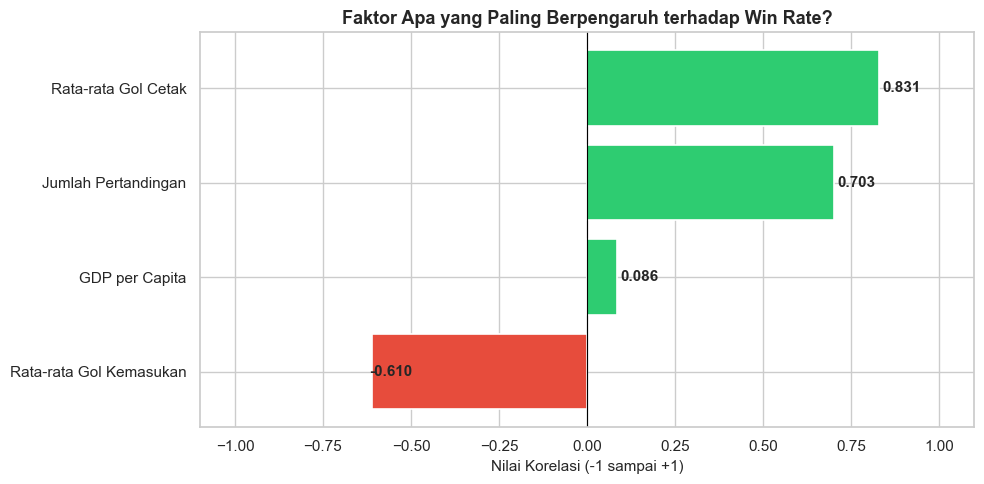

In [13]:
# Hitung korelasi setiap faktor terhadap win rate
factors = {
    'Rata-rata Gol Cetak'    : 'avg_goals_scored',
    'Rata-rata Gol Kemasukan': 'avg_goals_conceded',
    'Jumlah Pertandingan'    : 'total_matches',
    'GDP per Capita'         : 'gdp_avg',
}

correlations = {}
for label, col in factors.items():
    subset = team_full[['win_rate', col]].dropna()
    correlations[label] = subset['win_rate'].corr(subset[col])

corr_df = pd.DataFrame(list(correlations.items()), columns=['Faktor', 'Korelasi dengan Win Rate'])
corr_df = corr_df.sort_values('Korelasi dengan Win Rate', ascending=True)

print('Korelasi setiap faktor terhadap Win Rate:')
print(corr_df.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_df['Korelasi dengan Win Rate']]
bars = ax.barh(corr_df['Faktor'], corr_df['Korelasi dengan Win Rate'],
               color=colors_bar, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, corr_df['Korelasi dengan Win Rate']):
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=11)

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Nilai Korelasi (-1 sampai +1)', fontsize=11)
ax.set_title('Faktor Apa yang Paling Berpengaruh terhadap Win Rate?',
             fontsize=13, fontweight='bold')
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.show()

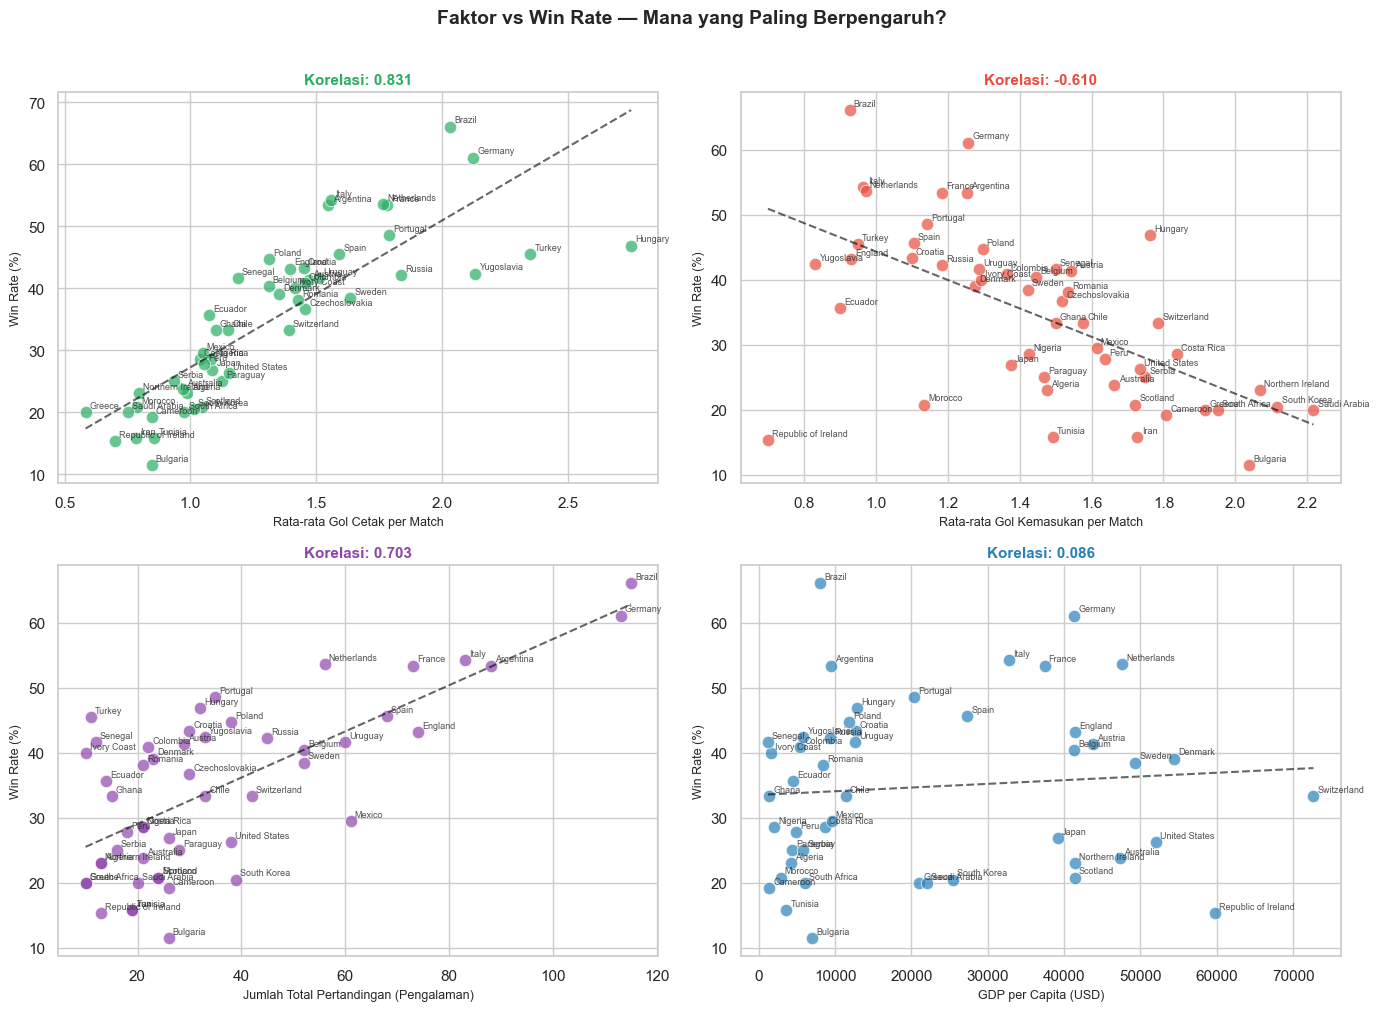

In [14]:
# Scatter plot 4 faktor sekaligus
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('avg_goals_scored',    'Rata-rata Gol Cetak per Match',      '#27ae60'),
    ('avg_goals_conceded',  'Rata-rata Gol Kemasukan per Match',  '#e74c3c'),
    ('total_matches',       'Jumlah Total Pertandingan (Pengalaman)', '#8e44ad'),
    ('gdp_avg',             'GDP per Capita (USD)',               '#2980b9'),
]

for ax, (col, xlabel, color) in zip(axes, plot_configs):
    subset = team_full[['team', 'win_rate', col]].dropna()
    corr_val = subset['win_rate'].corr(subset[col])

    ax.scatter(subset[col], subset['win_rate'] * 100,
               alpha=0.7, s=80, color=color, edgecolors='white', linewidth=0.7)

    for _, row in subset.iterrows():
        ax.annotate(row['team'], xy=(row[col], row['win_rate'] * 100),
                    xytext=(3, 3), textcoords='offset points', fontsize=6.5, alpha=0.8)

    z = np.polyfit(subset[col], subset['win_rate'] * 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='black', linewidth=1.5, alpha=0.6)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Win Rate (%)', fontsize=9)
    ax.set_title(f'Korelasi: {corr_val:.3f}', fontsize=11, fontweight='bold', color=color)

plt.suptitle('Faktor vs Win Rate — Mana yang Paling Berpengaruh?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

Dari grafik di atas, kita bisa rangkum:

| Faktor | Korelasi | Artinya |
|---|---|---|
| 🟢 **Rata-rata gol cetak** | Kuat positif | Tim yang sering cetak gol = tim yang sering menang. Masuk akal! |
| 🔴 **Rata-rata gol kemasukan** | Kuat negatif | Tim yang sering kemasukan = tim yang sering kalah. |
| 🟣 **Jumlah pertandingan** | Sedang positif | Tim yang sudah banyak main = lebih berpengalaman = cenderung menang. |
| 🔵 **GDP per capita** | Lemah positif | Kekayaan negara tidak terlalu berpengaruh langsung. |

> **Intinya:** Yang paling menentukan kemenangan adalah **seberapa bagus menyerang dan bertahan**, bukan seberapa kaya negaranya. GDP hanya faktor kecil di luar lapangan.

### 📊 Bonus: Heatmap Korelasi Antar Semua Faktor

Heatmap adalah grafik **kotak-kotak berwarna** yang menunjukkan seberapa kuat hubungan antara dua variabel.

- **Warna hijau/biru tua** = korelasi positif kuat (naik bareng)
- **Warna merah/oranye tua** = korelasi negatif kuat (satu naik, yang lain turun)
- **Warna putih/pucat** = tidak ada hubungan

Kita bisa lihat **semua hubungan sekaligus** dalam satu grafik.

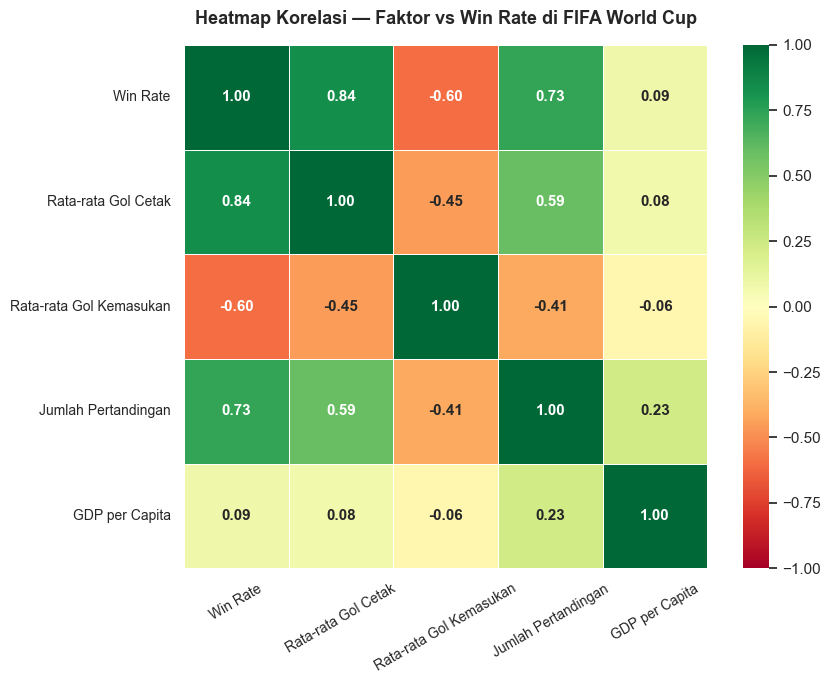

Cara baca: angka mendekati +1 = hubungan positif kuat | mendekati -1 = hubungan negatif kuat | mendekati 0 = tidak ada hubungan


In [15]:

# Siapkan data numerik untuk heatmap
heatmap_data = team_full[['win_rate', 'avg_goals_scored', 'avg_goals_conceded', 'total_matches', 'gdp_avg']].dropna()

# Ganti nama kolom supaya lebih mudah dibaca
heatmap_data = heatmap_data.rename(columns={
    'win_rate'            : 'Win Rate',
    'avg_goals_scored'    : 'Rata-rata Gol Cetak',
    'avg_goals_conceded'  : 'Rata-rata Gol Kemasukan',
    'total_matches'       : 'Jumlah Pertandingan',
    'gdp_avg'             : 'GDP per Capita',
})

# Hitung korelasi
corr_matrix = heatmap_data.corr()

# Buat heatmap
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,           # tampilkan angka di tiap kotak
    fmt='.2f',            # 2 angka di belakang koma
    cmap='RdYlGn',        # merah = negatif, kuning = netral, hijau = positif
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_title('Heatmap Korelasi — Faktor vs Win Rate di FIFA World Cup',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

print('Cara baca: angka mendekati +1 = hubungan positif kuat | mendekati -1 = hubungan negatif kuat | mendekati 0 = tidak ada hubungan')


### 💡 Cara Baca Heatmap

Fokus ke **baris Win Rate** (baris pertama) — itu yang paling penting:

| Kotak | Warna | Artinya |
|---|---|---|
| Win Rate ↔ Rata-rata Gol Cetak | 🟢 Hijau tua | Sering cetak gol = sering menang |
| Win Rate ↔ Rata-rata Gol Kemasukan | 🔴 Merah tua | Sering kemasukan = sering kalah |
| Win Rate ↔ Jumlah Pertandingan | 🟡 Hijau muda | Pengalaman sedikit berpengaruh |
| Win Rate ↔ GDP per Capita | ⬜ Kuning/putih | Kekayaan negara tidak terlalu berpengaruh |

Kotak diagonal (pojok kiri atas ke kanan bawah) selalu **1.00** karena setiap variabel berkorelasi sempurna dengan dirinya sendiri.

> **Intinya:** Heatmap ini sekaligus memperlihatkan semua hubungan. Terlihat jelas bahwa **gol cetak dan gol kemasukan adalah faktor terkuat** — jauh lebih kuat dari GDP.

---
## ❓ Pertanyaan 7: Skor berapa yang paling sering muncul?

Pertanyaan sederhana tapi menarik: dari ratusan pertandingan World Cup, skor berapa yang paling sering terjadi?

10 skor paling sering di FIFA World Cup:
Scoreline  Frekuensi
    1 - 0        102
    1 - 1         97
    2 - 1         96
    0 - 1         82
    0 - 0         79
    2 - 0         66
    1 - 2         57
    0 - 2         47
    3 - 1         38
    2 - 2         37


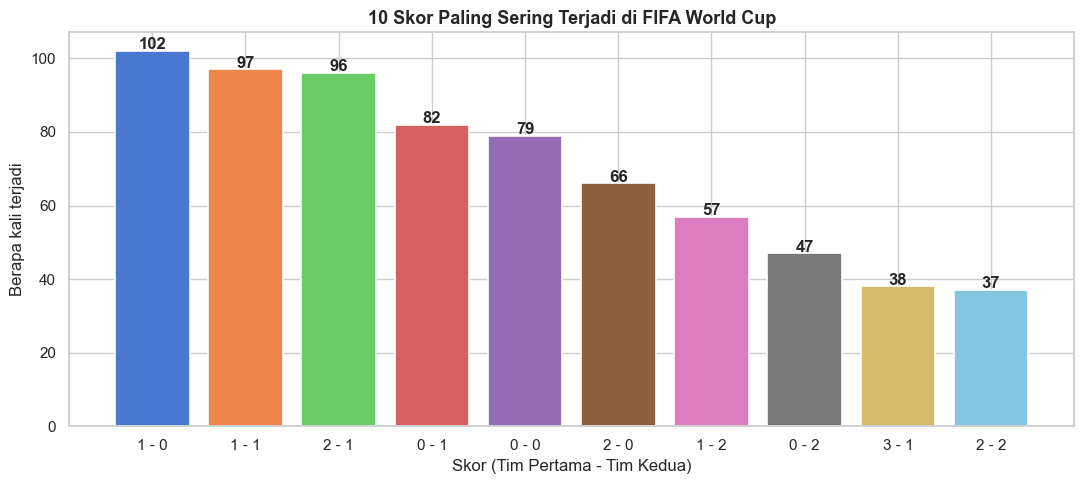

In [16]:
df['scoreline'] = df['home_score'].astype(str) + ' - ' + df['away_score'].astype(str)
top_scores = df['scoreline'].value_counts().head(10).reset_index()
top_scores.columns = ['Scoreline', 'Frekuensi']

print('10 skor paling sering di FIFA World Cup:')
print(top_scores.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_scores['Scoreline'], top_scores['Frekuensi'],
              color=sns.color_palette('muted', 10), edgecolor='white', linewidth=1.2)

ax.set_title('10 Skor Paling Sering Terjadi di FIFA World Cup',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Skor (Tim Pertama - Tim Kedua)')
ax.set_ylabel('Berapa kali terjadi')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 💡 Kesimpulan

- **1-0 adalah skor paling sering** — menang tipis satu gol adalah yang paling umum. Di level World Cup, semua tim sudah sangat kuat sehingga susah menang dengan selisih besar.
- **0-0 juga cukup sering** — ini menunjukkan bahwa pertahanan di level internasional sangat kuat.
- Skor **2-0 dan 2-1** juga sangat umum — kemenangan dengan 1-2 gol adalah standar.
- Skor besar seperti **5-0 atau 7-1** sangat jarang terjadi — tapi kalau terjadi, biasanya jadi momen bersejarah.

> **Intinya:** Di World Cup, kebanyakan pertandingan berakhir dengan skor kecil. Ini yang membuat sepak bola susah diprediksi — perbedaan antara menang dan kalah sering hanya 1 gol.

---
## ✅ Rangkuman EDA

| Pertanyaan | Temuan |
|---|---|
| Distribusi hasil | Menang sedikit lebih sering, data cukup seimbang untuk ML |
| Tim terkuat | Brazil, Jerman, Argentina konsisten di atas |
| Tren gol | Makin ke sini makin sedikit gol — pertahanan makin kuat |
| Home advantage | Ada, tapi kecil — kualitas tim lebih menentukan |
| GDP vs menang | Lemah — Qatar kaya tapi kalah, Brazil biasa tapi juara |
| Faktor terkuat | Gol cetak & gol kemasukan (serangan + pertahanan) |
| Skor tersering | 1-0 — kemenangan tipis adalah norma di World Cup |

### Fitur yang akan dibawa ke Model ML:
- `home_win_rate` & `away_win_rate`
- `win_rate_diff`
- `neutral`

➡️ Lanjut ke **Notebook 04 — Modeling**